<a href="https://colab.research.google.com/github/va4756/bigdata_raejung/blob/main/MachineLearning_%EA%B5%90%EA%B3%BC%EC%84%9C_%EB%B0%95%ED%95%B4%EC%84%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## chap 02

### 02-1.객체 지향 퍼셉트론 API

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

In [3]:
class Perceptron(object):
    # 퍼셉트론 분류기
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        # 훈련 데이터 학습
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update !=0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        # 입력 계산
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        # 단위 계단 함수를 사용하여 클래스 레이블을 반환
        return np.where(self.net_input(X) >= 0.0, 1, -1)

In [4]:
v1 = np.array([1,2,3])
v2 = 0.5 * v1
np.arccos(v1.dot(v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

np.float64(0.0)

### 02-2.붓꽃 데이터셋에서 퍼셉트론 훈련

#### 02-2-1 붓꽃 데이터셋 읽기

In [7]:
import os
import pandas as pd

s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
print('URL:', s)

df = pd.read_csv(s, header=None, encoding='utf-8')
print(df.shape)
df.head()

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
(150, 5)


,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#### 02-2-2 붓꽃 데이터 그래프 그리기

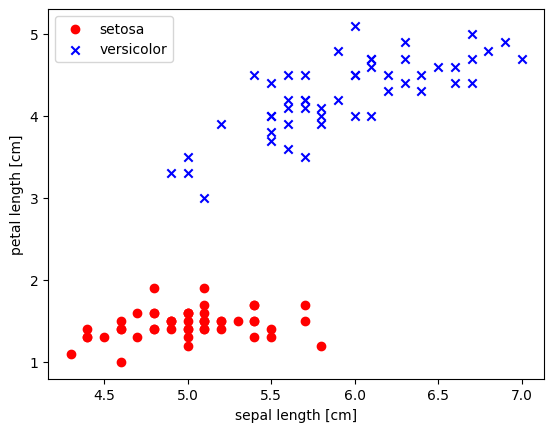

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# setosa와 versicolor를 선택
y = df.iloc[0:100, 4].values
y= np.where(y == 'Iris-setosa', -1, 1)

# 꽃받침 길이와 꽃잎 길이를 추출
X = df.iloc[0:100, [0, 2]].values

# 산점도
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='x', label='versicolor')

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

# plt.savefig('images/02_06.png', dpi=300)
plt.show()

#### 02-2-3 퍼셉트론 모델 훈련하기

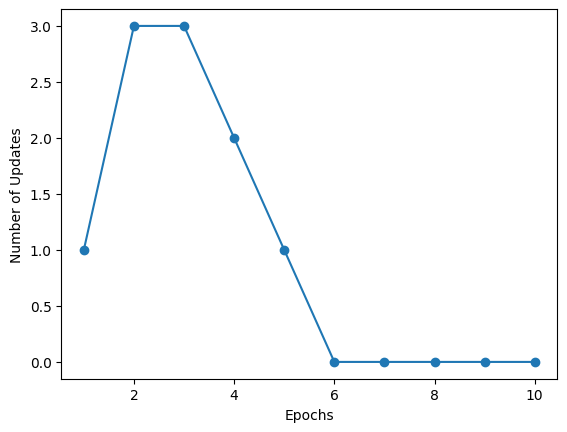

In [16]:
from matplotlib import markers
ppn = Perceptron(eta=0.1, n_iter=10)

ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of Updates')

# plt.savefig('images/02_07.png', dpi=300)
plt.show()

#### 02-2-4 결정 경계 그래프 함수

In [17]:
from matplotlib.colors import ListedColormap

In [ ]:
def plot_descision_regions(X, y, classifier, resolution=0.02):
    # 마커와 컬러맵을 설정
